# Imports

In [1]:
import sys
import os
# Tell Python to look two folders up (the project root) so it can find 'src'
sys.path.append(os.path.abspath('../../'))

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from src.utils.paths import PROCESSED_DATA_DIR
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Baseline Logistic Regression

In [2]:
# 1. Load the clean, scaled data
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").values.ravel()
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").values.ravel()
# 2. Initialize the Logistic Regression model
# We set max_iter=1000 to ensure the math has enough time to converge
log_reg = LogisticRegression(max_iter=1000)

# 3. Train the model
log_reg.fit(X_train, y_train)
print("Logistic Regression Model trained successfully!")

# 4. Make Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Logistic Regression Model trained successfully!
Accuracy: 0.9672544080604534
ROC AUC Score: 0.955935513043654


## Baseline Logistic Regression Analysis

- Logistic Regression is a **linear model** that separates classes using a linear decision boundary.

- Accuracy: **0.965**
- ROC AUC: **0.957**

### Observations

- Performance is stable and consistent due to low model complexity.
- The model shows a slight bias toward the majority class (extroverts).
- Introverts are harder to separate, suggesting overlap between classes in feature space.
### Takeaway

- Strong and reliable baseline.
- Limited by linear decision boundary → cannot capture complex patterns.

In [3]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      4115
           1       0.95      0.93      0.94      1443

    accuracy                           0.97      5558
   macro avg       0.96      0.95      0.96      5558
weighted avg       0.97      0.97      0.97      5558



### Classification Report Insights

- Class 0 (Extrovert):
  - Higher precision and recall
  - Most extroverts are correctly classified

- Class 1 (Introvert):
  - Lower recall
  - Some introverts are misclassified as extroverts

### Key Insight

- Mild bias toward the majority class (extroverts)
- Minority class separation is weaker

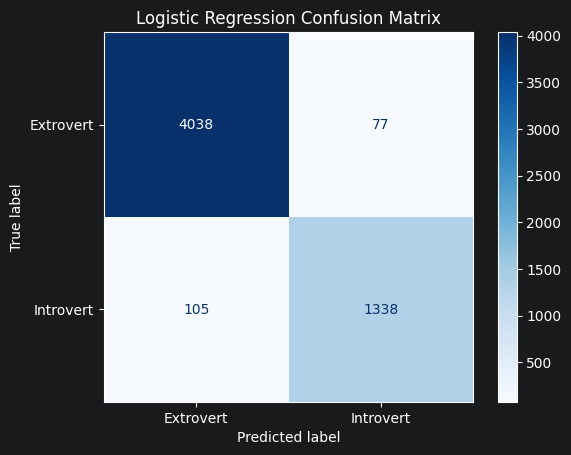

In [4]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Extrovert", "Introvert"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

- High values on the diagonal → most samples correctly classified
- Errors are mostly introverts predicted as extroverts

### Takeaway

- Confirms bias toward majority class
- Minority class recall is the main weakness

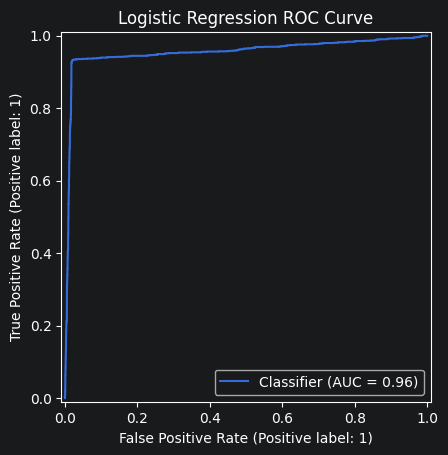

In [5]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Logistic Regression ROC Curve")
plt.show()

### ROC Curve Interpretation

- Curve close to top-left → strong separability
- High ROC AUC confirms good ranking ability

### Takeaway

- Model distinguishes classes well despite linear limitations

In [6]:
print("Train accuracy:", log_reg.score(X_train, y_train))
print("Test accuracy:", log_reg.score(X_test, y_test))

Train accuracy: 0.9693043344130804
Test accuracy: 0.9672544080604534


## Generalization Analysis

- Train accuracy: **{log_reg.score(X_train, y_train):.3f}**
- Test accuracy: **{log_reg.score(X_test, y_test):.3f}**

### Interpretation

- Very small gap → good generalization
- No signs of overfitting

### Takeaway

- Model is stable but limited by its linear nature

In [7]:
feature_importance = pd.Series(
    log_reg.coef_[0],
    index=X_train.columns
)

print("\nFeature Coefficients:\n", feature_importance.sort_values(ascending=False))


Feature Coefficients:
 Drained_after_socializing    1.642925
Stage_fear                   1.593407
Time_spent_Alone             0.706420
Going_outside               -0.314464
Friends_circle_size         -0.381531
Social_event_attendance     -0.467195
Post_frequency              -0.518559
dtype: float64


## Feature Importance Analysis (Coefficients)

### Interpretation

- Positive coefficients → push toward **Introvert**
- Negative coefficients → push toward **Extrovert**

### Observations

- Features with largest absolute coefficients dominate predictions
- Relationships are strictly linear

### Takeaway

- Highly interpretable
- Cannot capture feature interactions

## Limitations

- Assumes linear relationships
- Cannot model complex patterns
- Struggles with overlapping classes
- Sensitive to correlated features

## Final Conclusion

- Logistic Regression provides a **stable and interpretable baseline**
- Good generalization, no overfitting

- Main limitation:
  - Linear decision boundary → reduced performance on complex data

### Final Takeaway

- Solid baseline
- Outperformed by non-linear models on this dataset

In [13]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression

# 1. Define the model
# We set the solver to 'saga' as it fully supports the modern l1_ratio parameter
model = LogisticRegression(random_state=42, max_iter=5000, solver='saga')

# 2. Define the Inner and Outer Cross-Validation strategies
inner_cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=42)
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# 3. Define the modern search space
# Using l1_ratio instead of 'penalty' to avoid deprecation warnings
space = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0]  # 0.0 acts exactly like 'l2', 1.0 acts exactly like 'l1'
}

# 4. Define the Inner Loop (The Search)
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=space,
    n_iter=12,  # 6 C values * 2 l1_ratios = 12 total combinations, so it searches all of them
    scoring='accuracy',
    n_jobs=-1,
    cv=inner_cv,
    random_state=42
)

# 5. Define the Outer Loop (The Evaluation)
nested_scores = cross_val_score(
    estimator=search,
    X=X_train,
    y=y_train,
    cv=outer_cv,
    scoring='accuracy',
    n_jobs=-1
)

# 6. Finally, train the best model on the FULL training set
search.fit(X_train, y_train)

# 7. View the results
print(f"Nested CV Accuracy Scores (across all outer folds):\n{nested_scores}")
print(f"\nExpected Generalization Accuracy: {np.mean(nested_scores):.3f} +/- {np.std(nested_scores):.3f}")

print(f"\nBest parameters found: {search.best_params_}")
print(f"Best accuracy (Inner CV): {search.best_score_}")

Nested CV Accuracy Scores (across all outer folds):
[0.97455667 0.96914771 0.96529117 0.96914771 0.96760509 0.97224364
 0.96683378 0.96876205 0.97030467 0.96799074 0.96877409 0.96683378
 0.97184728 0.96914771 0.9683764 ]

Expected Generalization Accuracy: 0.969 +/- 0.002

Best parameters found: {'l1_ratio': 1.0, 'C': 0.1}
Best accuracy (Inner CV): 0.9693043344130802
